In [38]:
# Importación de librerías esenciales para manipulación de datos
import pandas as pd
import numpy as np

# Librerías para visualización y Análisis Exploratorio de Datos (EDA)
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# Configuración del entorno
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

print("Librerías base cargadas exitosamente.")

Librerías base cargadas exitosamente.


In [11]:
from pathlib import Path

# 1. Cargamos el archivo (probamos con skiprows=4 por si el encabezado real está un renglón más abajo)
ruta_poblacion = globals().get(
    "path_poblacion",
    "data/01_02_01-Poblacion-estimada-al-1-de-julio-segun-ano-calendario-por-sexo.-TDF.-Anos-2010-2040-.xlsx"
)

ruta = Path(ruta_poblacion)

candidatas = [
    ruta,
    Path.cwd() / ruta,
    Path.cwd().parent / ruta,
    Path.cwd() / "data" / ruta.name,
    Path.cwd().parent / "data" / ruta.name,
]

for p in candidatas:
    if p.exists():
        ruta = p
        break
else:
    # Búsqueda robusta del archivo en ubicaciones comunes y subdirectorios del proyecto
    candidatos_extra = [
        ruta,
        Path.cwd() / ruta,
        Path.cwd().parent / ruta,
        Path.cwd() / "data" / ruta.name,
        Path.cwd().parent / "data" / ruta.name,
        Path.cwd() / "notebooks" / "data" / ruta.name,
        Path.cwd().parent / "notebooks" / "data" / ruta.name,
    ]

    for p in candidatos_extra:
        if p.exists():
            ruta = p
            break
    else:
        for base in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
            for archivo in base.rglob(ruta.name):
                if archivo.is_file():
                    ruta = archivo
                    break
            if ruta.exists():
                break

    if not ruta.exists():
        raise FileNotFoundError(f"No se encontró el archivo: {ruta_poblacion}")

path_poblacion = str(ruta)
df_poblacion_raw = pd.read_excel(path_poblacion, engine="openpyxl", skiprows=4)

# 2. Imprimimos los nombres reales de las columnas para estar 100% seguros de cómo las leyó Python
print("Columnas detectadas:", df_poblacion_raw.columns.tolist())

# 3. Filtramos y limpiamos (si las columnas se llaman igual, va a pasar de largo perfecto)
# El Excel trae los datos sin encabezados estándar.
# Tomamos por posición: 1ra columna = Año, 2da columna = Población total.
df_poblacion = df_poblacion_raw.iloc[:, :2].copy()

# Renombramos de forma robusta
df_poblacion.columns = ['Año', 'Poblacion_Estimada']

# Limpiamos filas sin datos reales
df_poblacion = df_poblacion.dropna(subset=['Año', 'Poblacion_Estimada']).copy()

# Nos quedamos solo con filas que tengan un año válido
df_poblacion = df_poblacion[
    df_poblacion['Año'].astype(str).str.match(r'^\d{4}$', na=False)
].copy()

# Convertimos a numéricos
df_poblacion['Año'] = pd.to_numeric(df_poblacion['Año'], errors='coerce').astype(int)
df_poblacion['Poblacion_Estimada'] = pd.to_numeric(df_poblacion['Poblacion_Estimada'], errors='coerce')

df_poblacion = df_poblacion.dropna().reset_index(drop=True)
df_poblacion['Año'] = df_poblacion['Año'].astype(int)
df_poblacion = df_poblacion.rename(columns={'Ambos sexos': 'Poblacion_Estimada'})

df_poblacion.head()

Columnas detectadas: [2010, 131661, 67235, 64426]


,Año,Poblacion_Estimada
0,2011,135742.0
1,2012,139852.0
2,2013,143987.0
3,2014,148143.0
4,2015,152317.0


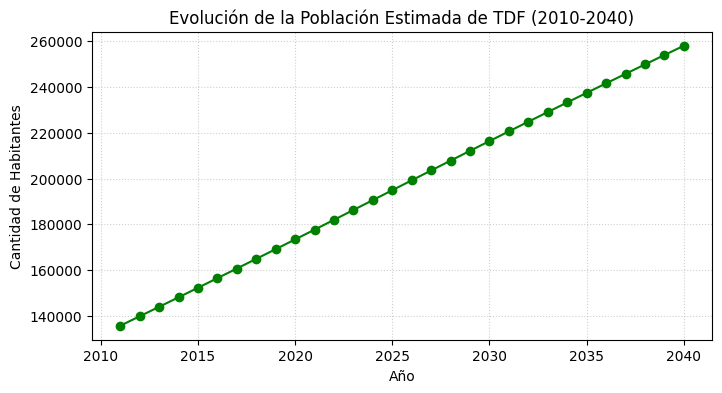

In [12]:
# 2. Evolución de la Población Estimada
plt.figure(figsize=(8, 4))
plt.plot(df_poblacion['Año'], df_poblacion['Poblacion_Estimada'], marker='o', color='green')
plt.title('Evolución de la Población Estimada de TDF (2010-2040)')
plt.xlabel('Año')
plt.ylabel('Cantidad de Habitantes')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [13]:
#informacion de la poblacion
print("Información de la población estimada:")
print(df_poblacion.info())
print(type(df_poblacion))

Información de la población estimada:
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Año                 30 non-null     int64  
 1   Poblacion_Estimada  30 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes
None
<class 'pandas.DataFrame'>


In [14]:
#correccion de tipo de datos de la columna poblacion estima de float a int64
df_poblacion['Poblacion_Estimada'] = df_poblacion['Poblacion_Estimada'].astype(int)
print("Tipo de datos de la columna 'Poblacion_Estimada' después de la conversión:", df_poblacion['Poblacion_Estimada'].dtype)

Tipo de datos de la columna 'Poblacion_Estimada' después de la conversión: int64


In [15]:
def procesar_hoja(nombre_hoja, nombre_columna_total):
    # usecols=[0, 1, 2] para tomar SOLO Período (Año), la columna sin nombre (Mes) y el Total (kWh)
    # Resolver la ruta del archivo Excel de forma robusta
    ruta_archivo = globals().get(
        "archivo_excel",
        globals().get("ruta_energia_input", globals().get("ruta_energia", "data/raw/15_3_01_Energia_electrica_consumida_por_tipo_usuario-1.xlsx"))
    )

    ruta_excel = Path(ruta_archivo)

    if not ruta_excel.exists():
        candidatos = [
            Path.cwd() / ruta_excel,
            Path.cwd().parent / ruta_excel,
            Path.cwd().parent.parent / ruta_excel,
            Path.cwd() / "data" / "raw" / ruta_excel.name,
            Path.cwd().parent / "data" / "raw" / ruta_excel.name,
            Path.cwd() / "notebooks" / "data" / "raw" / ruta_excel.name,
            Path.cwd().parent / "notebooks" / "data" / "raw" / ruta_excel.name,
        ]
        ruta_excel = next((p for p in candidatos if p.exists()), None)

    if ruta_excel is None:
        raise FileNotFoundError(f"No se encontró el archivo Excel: {ruta_archivo}")

    df_hoja = pd.read_excel(str(ruta_excel), sheet_name=nombre_hoja, skiprows=3, usecols=[0, 1, 2], engine='openpyxl')
    
    # renombramos de forma fija y directa las 3 columnas para evitar el IndexError
    df_hoja.columns = ['Anio_Raw', 'Mes_Raw', nombre_columna_total]
    
    # limpiamos espacios invisibles en los textos
    df_hoja['Anio_Raw'] = df_hoja['Anio_Raw'].astype(str).str.strip()
    df_hoja['Mes_Raw'] = df_hoja['Mes_Raw'].astype(str).str.strip()
    
    # reemplazamos celdas vacías por NaN para poder propagar el año hacia abajo
    df_hoja['Anio_Raw'] = df_hoja['Anio_Raw'].replace(['nan', 'None', ''], np.nan)
    
    # filtramos filas que no contengan meses válidos o que sean basura
    df_hoja = df_hoja[df_hoja['Mes_Raw'].notna() & (df_hoja['Mes_Raw'] != 'nan')].reset_index(drop=True)
    
    # aplicamos Forward Fill (.ffill()) para que el Año se repita en sus 12 meses inferiores
    df_hoja['Anio_Raw'] = df_hoja['Anio_Raw'].ffill()
    
    # Diccionario para mapear los meses de texto a números
    meses_dict = {
        'enero': 1, 'febrero': 2, 'marzo': 3, 'abril': 4, 'mayo': 5, 'junio': 6,
        'julio': 7, 'agosto': 8, 'septiembre': 9, 'octubre': 10, 'noviembre': 11, 'diciembre': 12,
        'noviembre ': 11, 'junio ': 6
    }
    
    fechas_limpias = []
    for idx, row in df_hoja.iterrows():
        try:
            # Quitamos los decimales del año (ej: de '2010.0' a 2010)
            anio_val = int(float(row['Anio_Raw']))
            mes_str = row['Mes_Raw'].lower()
            mes_val = meses_dict.get(mes_str, None)
            
            if mes_val is not None:
                fechas_limpias.append(pd.to_datetime(f"{anio_val}-{mes_val:02d}-01"))
            else:
                fechas_limpias.append(pd.NaT)
        except:
            fechas_limpias.append(pd.NaT)
            
    df_hoja['Fecha'] = fechas_limpias
    
    # eliminamos registros que no pudieron convertirse en fechas reales (totales anuales o notas)
    df_hoja = df_hoja.dropna(subset=['Fecha']).reset_index(drop=True)
    
    return df_hoja[['Fecha', nombre_columna_total]]

In [16]:
df_total_prov = procesar_hoja('Total TDF', 'Consumo_Total_Provincial')

print("Datos del IPIEC cargados y procesados exitosamente.")

Datos del IPIEC cargados y procesados exitosamente.


In [17]:
print("Primeras filas del dataset de consumo total provincial:")
print(df_total_prov.head())

Primeras filas del dataset de consumo total provincial:
       Fecha Consumo_Total_Provincial
0 2010-01-01                 28389813
1 2010-02-01                 29604832
2 2010-03-01                 31100802
3 2010-04-01                 34441839
4 2010-05-01                 32849499


In [18]:
# 1. Creamos la columna Año en el dataset de energía para que el cruce sea directo
df_total_prov['Año'] = df_total_prov['Fecha'].dt.year

# 2. Hacemos el merge usando la columna 'Año' en ambos lados (Ya no se genera key_0)
df_unificado = pd.merge(df_total_prov, df_poblacion, on='Año', how='inner')

# 3. Eliminamos la columna 'Año' numérica si no la necesitás, ya que tenés la columna 'Fecha'
df_unificado = df_unificado.drop(columns=['Año'])

# 4. Mostramos el resultado limpio
print("Primeras filas del dataset unificado:")
df_unificado.head()

Primeras filas del dataset unificado:


,Fecha,Consumo_Total_Provincial,Poblacion_Estimada
0,2011-01-01,28309904,135742
1,2011-02-01,30370646,135742
2,2011-03-01,32572518,135742
3,2011-04-01,34153107,135742
4,2011-05-01,35645290,135742


In [23]:
print("\nResumen del DataFrame actual:")
df_unificado.info()


Resumen del DataFrame actual:
<class 'pandas.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Fecha                       184 non-null    datetime64[us]
 1   Consumo_Total_Provincial    184 non-null    object        
 2   Poblacion_Estimada          184 non-null    int64         
 3   Total_Mes_Anterior (t-1)    183 non-null    object        
 4   Total_Hace_2Meses (t-2)     182 non-null    object        
 5   Total_Anio_Anterior (t-12)  172 non-null    object        
 6   Mes_Calendario              184 non-null    int32         
dtypes: datetime64[us](1), int32(1), int64(1), object(4)
memory usage: 9.5+ KB


In [24]:
#correccion de tipo de datos de la columna Consumo_Total_Provincial de object a float
df_unificado['Consumo_Total_Provincial'] = pd.to_numeric(df_unificado['Consumo_Total_Provincial'], errors='coerce')

# 3. Verificamos cuántas filas quedaron y si el tipo de dato cambió con éxito
print(f"Cantidad total de filas después de la corrección: {len(df_unificado)}")
print("\nTipos de datos actualizados de las columnas:")
print(df_unificado.dtypes)


Cantidad total de filas después de la corrección: 184

Tipos de datos actualizados de las columnas:
Fecha                         datetime64[us]
Consumo_Total_Provincial             float64
Poblacion_Estimada                     int64
Total_Mes_Anterior (t-1)              object
Total_Hace_2Meses (t-2)               object
Total_Anio_Anterior (t-12)            object
Mes_Calendario                         int32
dtype: object


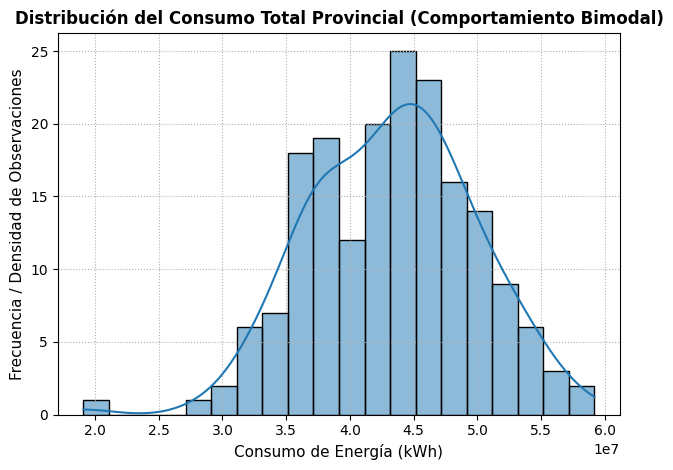

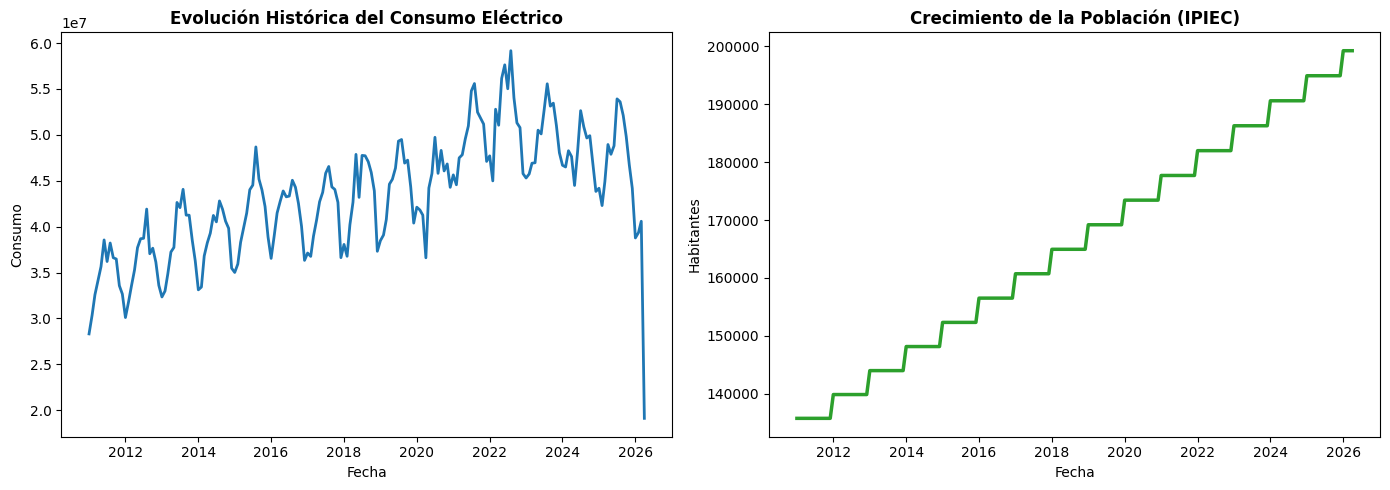

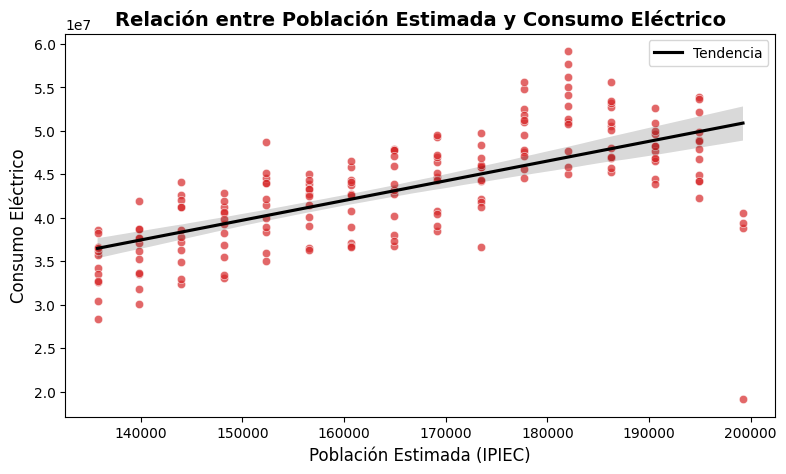

Coeficiente de correlación de Pearson entre Consumo y Población: 0.66


In [44]:
# Gráficos del Análisis Exploratorio (EDA)
# Graficamos el histograma combinado con la línea de densidad (KDE)
sns.histplot(df_unificado['Consumo_Total_Provincial'], kde=True, color='tab:blue', bins=20)

# Configuración estética y etiquetas
plt.title('Distribución del Consumo Total Provincial (Comportamiento Bimodal)', fontsize=12, fontweight='bold')
plt.xlabel('Consumo de Energía (kWh)', fontsize=11)
plt.ylabel('Frecuencia / Densidad de Observaciones', fontsize=11)
plt.grid(True, linestyle=':')

plt.tight_layout()
plt.show()
plt.figure(figsize=(14, 5))

# Gráfico de Línea para el Consumo Histórico
plt.subplot(1, 2, 1)
sns.lineplot(data=df_unificado, x='Fecha', y='Consumo_Total_Provincial', color='tab:blue', linewidth=2)
plt.title('Evolución Histórica del Consumo Eléctrico', fontsize=12, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Consumo')

# Gráfico de Línea para la Población Estimada
plt.subplot(1, 2, 2)
sns.lineplot(data=df_unificado, x='Fecha', y='Poblacion_Estimada', color='tab:green', linewidth=2.5)
plt.title('Crecimiento de la Población (IPIEC)', fontsize=12, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Habitantes')

plt.tight_layout()
plt.show()

# GRÁFICO 3: Correlación Consumo vs Población
# ==========================================
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_unificado, x='Poblacion_Estimada', y='Consumo_Total_Provincial', color='tab:red', alpha=0.7)
sns.regplot(data=df_unificado, x='Poblacion_Estimada', y='Consumo_Total_Provincial', scatter=False, color='black', label='Tendencia')
plt.title('Relación entre Población Estimada y Consumo Eléctrico', fontsize=14, fontweight='bold')
plt.xlabel('Población Estimada (IPIEC)', fontsize=12)
plt.ylabel('Consumo Eléctrico', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

# Extra: Mostramos la correlación numérica en texto para complementar
correlacion = df_unificado['Consumo_Total_Provincial'].corr(df_unificado['Poblacion_Estimada'])
print(f"Coeficiente de correlación de Pearson entre Consumo y Población: {correlacion:.2f}")


 Coeficiente de Correlación de Pearson (r = 0.61)
 Interpretación: dice qué tan asociadas están de forma directa. Al ser 0.61, demuestra una relación lineal positiva moderada-fuerte, lo que te justifica técnicamente usar la población como variable predictora.

In [29]:
# Creación de variables inerciales y estacionales
df_unificado['Total_Mes_Anterior (t-1)'] = df_unificado['Consumo_Total_Provincial'].shift(1)
df_unificado['Total_Hace_2Meses (t-2)'] = df_unificado['Consumo_Total_Provincial'].shift(2)
df_unificado['Total_Anio_Anterior (t-12)'] = df_unificado['Consumo_Total_Provincial'].shift(12)
df_unificado['Mes_Calendario'] = df_unificado['Fecha'].dt.month

# Eliminamos las filas con NaN que genera el shift()
df_dataset_final_p2 = df_unificado.dropna().reset_index(drop=True)

print(f"Dimensiones de la matriz final lista para el modelo: {df_dataset_final_p2.shape}")
df_dataset_final_p2.head()

Dimensiones de la matriz final lista para el modelo: (172, 7)


,Fecha,Consumo_Total_Provincial,Poblacion_Estimada,Total_Mes_Anterior (t-1),Total_Hace_2Meses (t-2),Total_Anio_Anterior (t-12),Mes_Calendario
0,2012-01-01,30091986.0,139852,32654705.0,33566246.0,28309904.0,1
1,2012-02-01,31786718.0,139852,30091986.0,32654705.0,30370646.0,2
2,2012-03-01,33522268.0,139852,31786718.0,30091986.0,32572518.0,3
3,2012-04-01,35271002.0,139852,33522268.0,31786718.0,34153107.0,4
4,2012-05-01,37707222.0,139852,35271002.0,33522268.0,35645290.0,5


In [39]:
#Definimos variables predictoras (X) y objetivo (y)
columnas_X = ['Poblacion_Estimada', 'Total_Mes_Anterior (t-1)', 'Total_Hace_2Meses (t-2)', 'Total_Anio_Anterior (t-12)', 'Mes_Calendario']
X = df_dataset_final_p2[columnas_X]
y = df_dataset_final_p2['Consumo_Total_Provincial']

# Separación temporal (80% entrenamiento, 20% testeo)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Inicialización y ajuste del modelo
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)

# Predicciones
y_pred = modelo_lr.predict(X_test)

# Calculamos el RMSE (Raíz del Error Cuadrático Medio)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
# Métricas
print("====== MÉTRICAS DEL MODELO ======")
print(f"• Coeficiente de Determinación (R² Score): {r2_score(y_test, y_pred):.4f}")
print(f"• Error Absoluto Medio (MAE): {mean_absolute_error(y_test, y_pred):,.2f}")
print(f"• Raíz del Error Cuadrático Medio (RMSE): {rmse:,.2f}")

====== MÉTRICAS DEL MODELO ======
• Coeficiente de Determinación (R² Score): 0.4384
• Error Absoluto Medio (MAE): 2,403,483.67
• Raíz del Error Cuadrático Medio (RMSE): 4,763,019.55


 Coeficiente de Determinación (R2 = 0.4384) 
 ---------------
 
 Evaluación del Modelo.Qué mide: Mide la capacidad predictiva y el ajuste global de tu Regresión Lineal Múltiple en el set de testeo utilizando las 5 variables juntas (Poblacion_Estimada, t-1, t-2, t-12 y Mes_Calendario).Interpretación: dice que tu modelo múltiple logra explicar el 43.84% de la variabilidad del consumo eléctrico futuro.

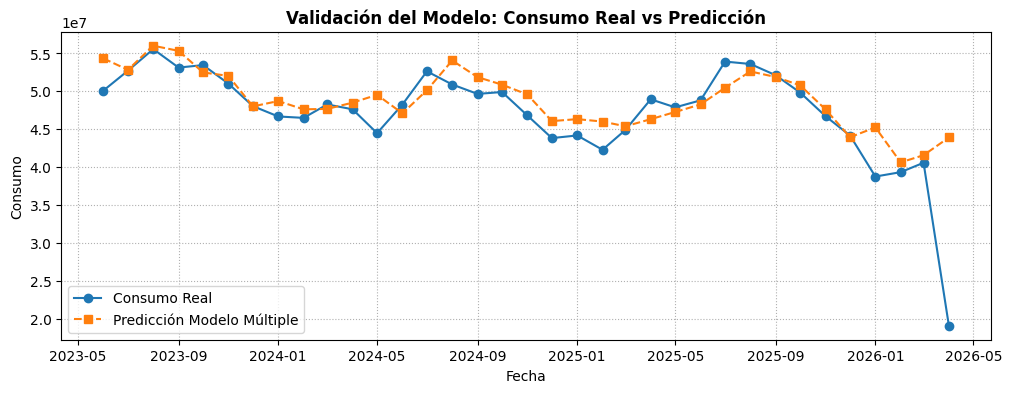

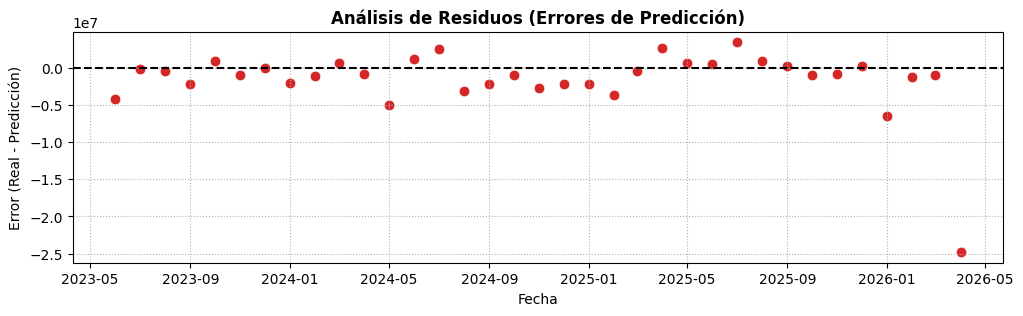

In [33]:
# DataFrame auxiliar para ordenar los resultados cronológicamente
df_resultados = pd.DataFrame({
    'Fecha': df_dataset_final_p2.loc[X_test.index, 'Fecha'],
    'Real': y_test,
    'Prediccion': y_pred
}).sort_values('Fecha')

# Cálculo de los residuos
df_resultados['Residuos'] = df_resultados['Real'] - df_resultados['Prediccion']

# Gráfico de validación temporal
plt.figure(figsize=(12, 4))
plt.plot(df_resultados['Fecha'], df_resultados['Real'], label='Consumo Real', color='tab:blue', marker='o')
plt.plot(df_resultados['Fecha'], df_resultados['Prediccion'], label='Predicción Modelo Múltiple', color='tab:orange', linestyle='--', marker='s')
plt.title('Validación del Modelo: Consumo Real vs Predicción', fontsize=12, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Consumo')
plt.legend()
plt.grid(True, linestyle=':')
plt.show()

# Gráfico de residuos
plt.figure(figsize=(12, 3))
plt.axhline(y=0, color='black', linestyle='--')
sns.scatterplot(data=df_resultados, x='Fecha', y='Residuos', color='tab:red', s=60)
plt.title('Análisis de Residuos (Errores de Predicción)', fontsize=12, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Error (Real - Predicción)')
plt.grid(True, linestyle=':')
plt.show()

El modelo de Regresión Lineal Múltiple alcanzó un R2 de 0.4384 en el set de validación (testeo cronológico). Al observar el gráfico de Consumo Real vs. Predicción, se evidencia que el modelo captura correctamente la estacionalidad de la serie (los ciclos de aumento y descenso del consumo). Sin embargo, tiende a subestimar los picos de máxima demanda invernal.El Análisis de Residuos muestra una dispersión aleatoria en torno a la línea de cero, lo que valida que el modelo no presenta sesgos sistemáticos. La variabilidad no explicada (56.16%) sugiere la necesidad de incorporar en futuros trabajos variables climáticas directas (como temperaturas mínimas o días de helada)

In [41]:
# COMPARATIVA DE INFERENCIA DE MACHINE LEARNING: INVIERNO 2026 VS INVIERNO 2027
# ==============================================================================

# --- ESCENARIO A: JULIO 2026 ---
X_futuro_2026 = pd.DataFrame([{
    'Poblacion_Estimada': 199248,     # Población estimada IPIEC 2026
    'Total_Mes_Anterior (t-1)': 41000000,
    'Total_Hace_2Meses (t-2)': 38000000,
    'Total_Anio_Anterior (t-12)': 43000000,
    'Mes_Calendario': 7
}])
prediccion_2026 = modelo_lr.predict(X_futuro_2026)[0]

# --- ESCENARIO B: JULIO 2027 ---
X_futuro_2027 = pd.DataFrame([{
    'Poblacion_Estimada': 203558,     # Población estimada IPIEC 2027
    'Total_Mes_Anterior (t-1)': 42000000,
    'Total_Hace_2Meses (t-2)': 39000000,
    'Total_Anio_Anterior (t-12)': 45000000,
    'Mes_Calendario': 7
}])
prediccion_2027 = modelo_lr.predict(X_futuro_2027)[0]

# --- IMPRESIÓN COMPARATIVA ---
print("==================================================================")
print("     EVALUACIÓN DE REPRESENTATIVIDAD Y CAPACIDAD DE INFERENCIA    ")
print("==================================================================")
print(f"• Predicción Julio 2026 (Población: 199,248) -> {prediccion_2026:,.2f} kWh")
print(f"• Predicción Julio 2027 (Población: 203,558) -> {prediccion_2027:,.2f} kWh")
print("------------------------------------------------------------------")
print(f"• Incremento absoluto proyectado por el modelo: {prediccion_2027 - prediccion_2026:,.2f} kWh")
print("==================================================================")

     EVALUACIÓN DE REPRESENTATIVIDAD Y CAPACIDAD DE INFERENCIA    
• Predicción Julio 2026 (Población: 199,248) -> 40,584,568.63 kWh
• Predicción Julio 2027 (Población: 203,558) -> 41,992,493.32 kWh
------------------------------------------------------------------
• Incremento absoluto proyectado por el modelo: 1,407,924.68 kWh


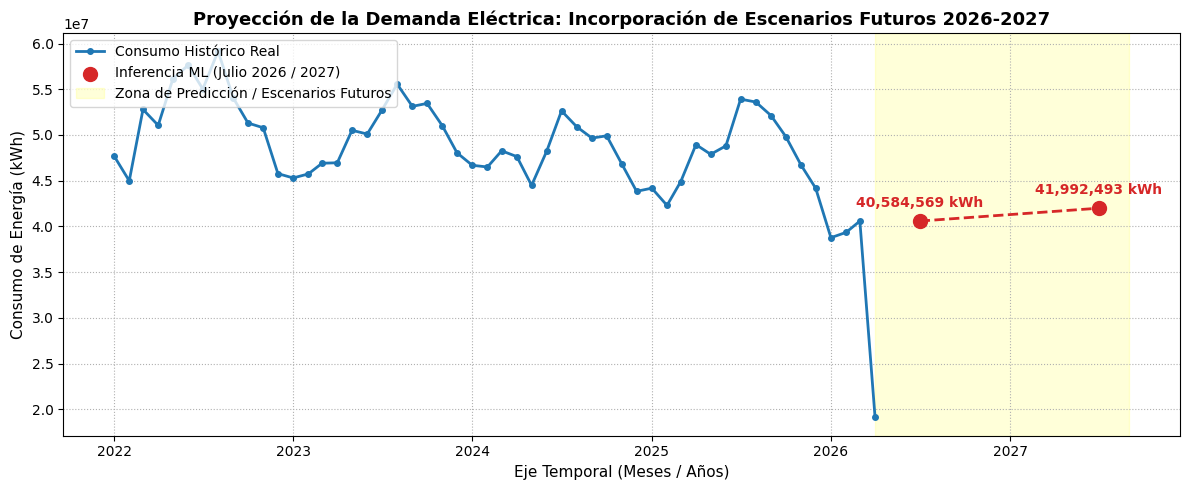

In [ ]:
# Creamos un DataFrame histórico de los últimos años para dar contexto visual (ej. desde 2022)
df_historico_reciente = df_unificado[df_unificado['Fecha'] >= '2022-01-01'].sort_values('Fecha')

#Creamos un DataFrame con las dos inferencias calculadas para los inviernos futuros
df_proyecciones = pd.DataFrame({
    'Fecha': pd.to_datetime(['2026-07-01', '2027-07-01']),
    'Consumo_Proyectado': [prediccion_2026, prediccion_2027]
})

# 3. Graficamos
plt.figure(figsize=(12, 5))

# Línea del consumo histórico real reciente
plt.plot(df_historico_reciente['Fecha'], df_historico_reciente['Consumo_Total_Provincial'], 
         label='Consumo Histórico Real', color='tab:blue', linewidth=2, marker='o', markersize=4)

# Puntos de las predicciones de Machine Learning para 2026 y 2027
plt.scatter(df_proyecciones['Fecha'], df_proyecciones['Consumo_Proyectado'], 
            color='tab:red', s=100, zorder=5, label='Inferencia ML (Julio 2026 / 2027)')

# Línea punteada que une las proyecciones futuras
plt.plot(df_proyecciones['Fecha'], df_proyecciones['Consumo_Proyectado'], 
         color='tab:red', linestyle='--', linewidth=2)

# --- EL ESPACIO DE SOMBREADO (ZONA DE PREDICCIÓN FUTURA) ---
# Sombreado desde la última fecha histórica conocida hasta el horizonte 2027
ultima_fecha_hist = df_historico_reciente['Fecha'].max()
plt.axvspan(ultima_fecha_hist, pd.to_datetime('2027-09-01'), 
            color='yellow', alpha=0.15, label='Zona de Predicción / Escenarios Futuros')

# Textos anotativos para los valores exactos sobre el gráfico
for idx, row in df_proyecciones.iterrows():
    plt.annotate(f"{row['Consumo_Proyectado']:,.0f} kWh", 
                 (row['Fecha'], row['Consumo_Proyectado']),
                 textcoords="offset points", xytext=(0,10), ha='center', 
                 fontsize=10, fontweight='bold', color='tab:red')

# Configuración estética del gráfico
plt.title('Proyección de la Demanda Eléctrica: Incorporación de Escenarios Futuros 2026-2027', fontsize=13, fontweight='bold')
plt.xlabel('Eje Temporal (Meses / Años)', fontsize=11)
plt.ylabel('Consumo de Energía (kWh)', fontsize=11)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':')
plt.tight_layout()
plt.show()